## Setup

In [ ]:
import sys
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

project_root_dir = "/opt/pubchem-cid4-analysis/py/"
if project_root_dir not in sys.path:
    sys.path.append(project_root_dir)
print(sys.path)

from src import log_settings  # noqa: E402
from src.ml.common import (  # noqa: E402
    RANDOM_SEED,
    PreparedDataset,
    build_supervised_split,
    regression_metrics,
)
from src.ml.datasets import (  # noqa: E402
    ATOM_SDF_FILENAME,
    BIOACTIVITY_FILENAME,
    build_atom_feature_frame,
    build_bioactivity_model_frame,
    build_molecular_descriptors,
)
from src.ml.xgboost_utils import ranked_feature_importances  # noqa: E402
from src.utils import fs_utils  # noqa: E402
from src.utils.json_utils import write_json  # noqa: E402

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)

log_settings.configure_logging()

['/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload', '', '/opt/pubchem-cid4-analysis/py/.venv/lib/python3.12/site-packages', '/opt/pubchem-cid4-analysis/py/']


# Notes

$w = (X^T X)^+ X^T y$


In [10]:
def load_bioactivity_dataframe() -> pd.DataFrame:
    return pd.read_csv(fs_utils.resolve_data_path(BIOACTIVITY_FILENAME))


def build_activity_value_regression_dataset(atom_filename: str = ATOM_SDF_FILENAME) -> PreparedDataset:
    bioactivity_df = load_bioactivity_dataframe()
    activity_value = pd.to_numeric(bioactivity_df["Activity_Value"], errors="coerce")
    retained_mask = activity_value.notna() & activity_value.gt(0)
    filtered_df = bioactivity_df.loc[retained_mask].copy()
    filtered_df["Activity_Value"] = activity_value.loc[retained_mask]
    atom_feature_df, molecule = build_atom_feature_frame(atom_filename)
    descriptor_map = build_molecular_descriptors(atom_feature_df, molecule)
    frame, feature_columns = build_bioactivity_model_frame(filtered_df, descriptor_map)

    return PreparedDataset(
        frame=frame,
        feature_columns=feature_columns,
        target_column="Activity_Value",
    )


def plot_regression_diagnostics(results: dict[str, Any], title_prefix: str) -> None:
    true_values = np.asarray(results["true_values"], dtype=np.float64)
    predicted_values = np.asarray(results["predicted_values"], dtype=np.float64)
    residuals = true_values - predicted_values

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.scatterplot(x=true_values, y=predicted_values, ax=axes[0], s=70, color="tab:blue")
    diagonal_min = min(true_values.min(), predicted_values.min())
    diagonal_max = max(true_values.max(), predicted_values.max())
    axes[0].plot([diagonal_min, diagonal_max], [diagonal_min, diagonal_max], linestyle="--", color="black")
    axes[0].set_title(f"{title_prefix}: predicted vs true")
    axes[0].set_xlabel("True activity value")
    axes[0].set_ylabel("Predicted activity value")

    sns.scatterplot(x=predicted_values, y=residuals, ax=axes[1], s=70, color="tab:orange")
    axes[1].axhline(0.0, linestyle="--", color="black")
    axes[1].set_title(f"{title_prefix}: residuals")
    axes[1].set_xlabel("Predicted activity value")
    axes[1].set_ylabel("Residual")

    fig.tight_layout()
    plt.show()


def plot_xgboost_training_history(results: dict[str, Any], metric: str = "rmse") -> None:
    training_history = results.get("training_history", {})
    metric_history = training_history.get(metric, {})
    train_metric = metric_history.get("train")
    validation_metric = metric_history.get("validation")
    if not train_metric or not validation_metric:
        raise ValueError(f"No training history available for metric '{metric}'.")

    rounds = np.arange(1, len(train_metric) + 1)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(rounds, train_metric, label=f"Train {metric.upper()}", linewidth=2)
    ax.plot(rounds, validation_metric, label=f"Validation {metric.upper()}", linewidth=2)
    ax.set_title(f"XGBoost training history ({metric.upper()})")
    ax.set_xlabel("Boosting round")
    ax.set_ylabel(metric.upper())
    ax.legend()
    fig.tight_layout()
    plt.show()


def run_linear_regression(dataset: PreparedDataset) -> dict[str, Any]:
    x_values = dataset.feature_matrix()
    y_values = dataset.target_vector()
    x_train, x_test, y_train, y_test = train_test_split(
        x_values,
        y_values,
        test_size=0.3,
        random_state=RANDOM_SEED,
    )

    y_train = y_train.astype(np.float64)
    design_matrix = np.column_stack([np.ones(len(x_train)), x_train])
    manual_coefficients = np.linalg.pinv(design_matrix.T @ design_matrix) @ design_matrix.T @ y_train

    model = LinearRegression()
    model.fit(x_train, y_train)
    display(model)
    predictions = model.predict(x_test)

    print(f"manual intercept: {float(manual_coefficients[0])}")
    print(f"manual coefficients: {manual_coefficients[1:].astype(float).tolist()}")

    print(f"intercept: {float(model.intercept_)}")
    print(f"coefficients: {model.coef_.astype(float).tolist()}")

    return {
        "metrics": regression_metrics(y_test.astype(np.float64), predictions.astype(np.float64)),
        "true_values": y_test.astype(np.float64).tolist(),
        "predicted_values": predictions.astype(np.float64).tolist(),
    }

INFO 2026-05-28T14:39:15+0000 env_utils.py get_data_dir 7 root 141 MainProcess 139791340577536 MainThread Task-2 Data directory: /opt/pubchem-cid4-analysis/py/../data
INFO 2026-05-28T14:39:15+0000 env_utils.py get_data_dir 7 root 141 MainProcess 139791340577536 MainThread Task-2 Data directory: /opt/pubchem-cid4-analysis/py/../data
INFO 2026-05-28T14:39:15+0000 env_utils.py get_data_dir 7 root 141 MainProcess 139791340577536 MainThread Task-2 Data directory: /opt/pubchem-cid4-analysis/py/../data


PosixPath('/opt/pubchem-cid4-analysis/py/../data/out')

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


manual intercept: 2.3701914861267015e-07
manual coefficients: [7.110574458378182e-07, 2.1331723375140318e-06, 2.3701914861267012e-07, 2.3701914861267012e-07, 3.0812489319647125e-06, 1.7802745271446265e-05, 2.3701914861267012e-07, 0.0, 2.3701914861267012e-07, 2.3701914861267012e-07, 2.3701914861267012e-07, 0.0, 0.00227680594157331, -2.3701914861267012e-07, 2.3701914861267012e-07, 2.3701914861267012e-07, 0.0, 2.3701914861267012e-07, 2.3701914861267012e-07, 0.0, 0.0, 2.3701914861267012e-07, 0.0, 0.0, 0.0, 0.0, 2.3701914861267012e-07, 0.0, 0.0, 0.0, 0.0, 2.3701914861267004e-07, 0.0, 0.0]
intercept: 21.8724
coefficients: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


{'metrics': {'mae': 778.1276, 'rmse': 778.1276, 'r2': None},
 'true_values': [800.0],
 'predicted_values': [21.8724]}

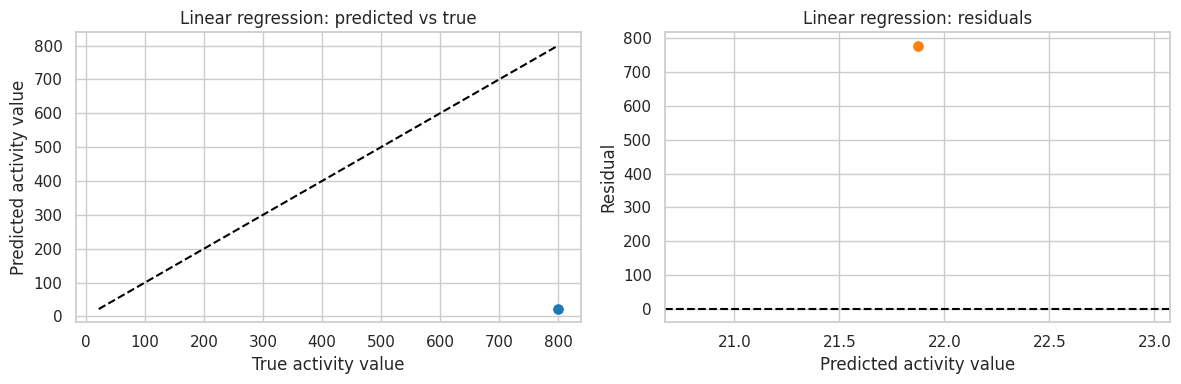

In [11]:
regression_dataset = build_activity_value_regression_dataset()

output_directory = fs_utils.resolve_output_directory()
display(output_directory)

write_json(regression_dataset.summary(), output_directory / "linear_regression_dataset_summary.json")

regression_dataset.frame.to_csv(output_directory / "cid4_ml.bioactivity_regression_features.csv", index=False)
linear_regression = run_linear_regression(regression_dataset)
display(linear_regression)
plot_regression_diagnostics(linear_regression, title_prefix="Linear regression")

## XGBoost regression

INFO 2026-05-28T13:52:10+0000 env_utils.py get_data_dir 7 root 141 MainProcess 139791340577536 MainThread Task-2 Data directory: /opt/pubchem-cid4-analysis/py/../data


INFO 2026-05-28T13:52:10+0000 env_utils.py get_data_dir 7 root 141 MainProcess 139791340577536 MainThread Task-2 Data directory: /opt/pubchem-cid4-analysis/py/../data


{'evaluation_note': 'Dataset is too small for a stable holdout split, so evaluation is reported on the training rows.',
 'metrics': {'mae': 1.4825946319580083,
  'rmse': 1.4825946328244406,
  'r2': 0.9999854787768722},
 'feature_importances': [{'feature': 'Activity_Type_Encoded',
   'importance': 0.417896568775177},
  {'feature': 'Has_Dose_Response_Curve', 'importance': 0.3661556541919708},
  {'feature': 'Bioassay_Data_Source_Encoded',
   'importance': 0.21594779193401337},
  {'feature': 'C_count', 'importance': 0.0},
  {'feature': 'H_count', 'importance': 0.0},
  {'feature': 'N_count', 'importance': 0.0},
  {'feature': 'O_count', 'importance': 0.0},
  {'feature': 'bond_count_total', 'importance': 0.0},
  {'feature': 'mol_weight', 'importance': 0.0},
  {'feature': 'has_chiral_center', 'importance': 0.0},
  {'feature': 'Aid_Type_Encoded', 'importance': 0.0},
  {'feature': 'RNAi_BioAssay', 'importance': 0.0},
  {'feature': 'Taxonomy_ID_Numeric', 'importance': 0.0},
  {'feature': 'Target_

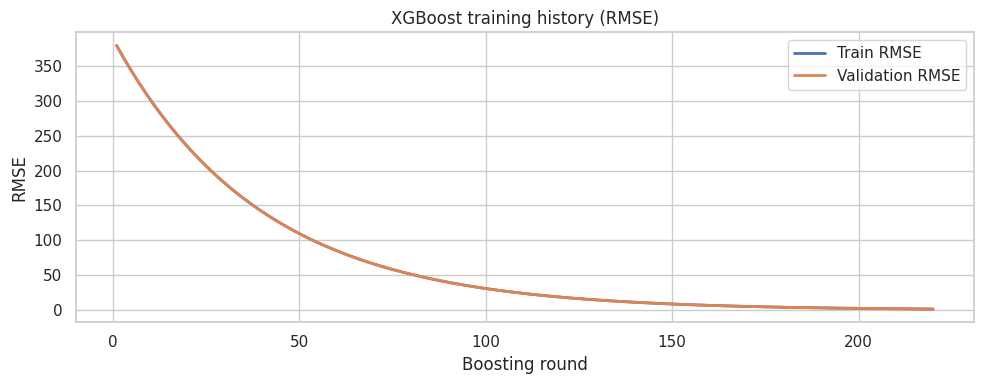

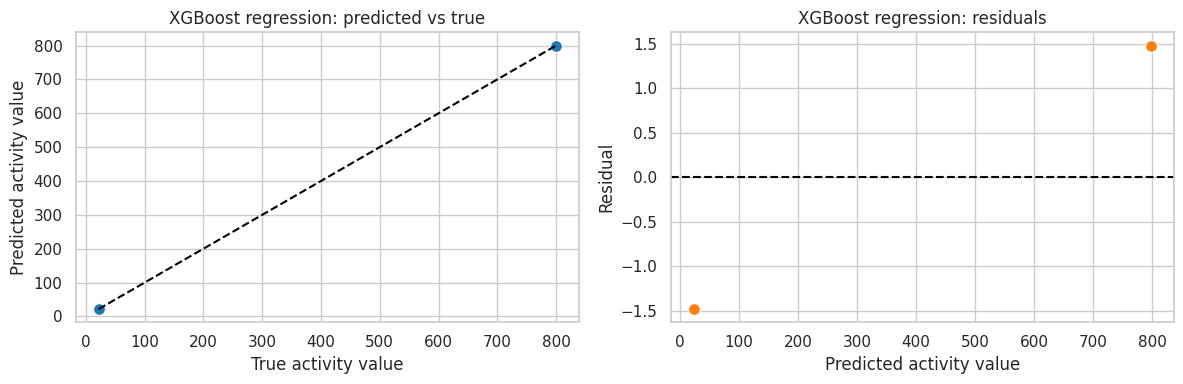

In [7]:
def run_xgboost_regression(dataset: PreparedDataset) -> dict[str, Any]:
    split = build_supervised_split(dataset, scale_features=False)
    model_kwargs: dict[str, Any] = {
        "n_estimators": 220,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "random_state": 42,
        "tree_method": "hist",
        "verbosity": 0,
        "objective": "reg:squarederror",
        "eval_metric": ["rmse", "mae"],
    }
    model = XGBRegressor(**model_kwargs)
    model.fit(
        split.x_train,
        split.y_train.astype(np.float64),
        eval_set=[
            (split.x_train, split.y_train.astype(np.float64)),
            (split.x_test, split.y_test.astype(np.float64)),
        ],
        verbose=False,
    )
    predictions = model.predict(split.x_test)
    evals_result = model.evals_result()

    training_history = {
        metric_name: {
            "train": values.astype(float).tolist() if hasattr(values, "astype") else [float(value) for value in values],
            "validation": validation_values.astype(float).tolist()
            if hasattr(validation_values, "astype")
            else [float(value) for value in validation_values],
        }
        for metric_name, values, validation_values in [
            (metric_name, evals_result["validation_0"][metric_name], evals_result["validation_1"][metric_name])
            for metric_name in evals_result["validation_0"]
        ]
    }

    return {
        "evaluation_note": split.evaluation_note,
        "metrics": regression_metrics(split.y_test.astype(np.float64), predictions.astype(np.float64)),
        "feature_importances": ranked_feature_importances(dataset, model.feature_importances_),
        "model_parameters": {
            "n_estimators": model_kwargs["n_estimators"],
            "max_depth": model_kwargs["max_depth"],
            "learning_rate": model_kwargs["learning_rate"],
            "objective": model_kwargs["objective"],
            "eval_metric": model_kwargs["eval_metric"],
        },
        "training_history": training_history,
        "true_values": split.y_test.astype(np.float64).tolist(),
        "predicted_values": predictions.astype(np.float64).tolist(),
    }


regression_dataset = build_activity_value_regression_dataset()
xgboost_regression = run_xgboost_regression(regression_dataset)
display(xgboost_regression)
plot_xgboost_training_history(xgboost_regression, metric="rmse")
plot_regression_diagnostics(xgboost_regression, title_prefix="XGBoost regression")